##### ***自注意力机制与位置编码***
###### 在以往的深度学习我们使用CNN或者RNN，但是它们有着显而易见的缺陷：内容受限。因为RNN和CNN前者是只看当前时间步和前面一段时间步的信息，后者是受限于卷积核的大小，所以它们无法处理长距离依赖关系。而自注意力机制输入同一组词元序列，但通过构建不同的权重矩阵，得到不同的Q、K、V，再经过计算注意力输出得到注意力分数。其中QK的点积表明了每个词元与其他词元的关系，然而缺点也非常明显，就是交换相邻两个词元的位置，计算结果不一样，这就需要引入位置编码。

In [22]:
import math 
import torch
from torch import nn
from d2l import torch as d2l

###### 具体用数学公式表示为：给定一个由词元组成的输入序列$x_1, \cdots, x_n$。该序列的自注意力输出为一个长度相同的序列$y_1, \cdots, y_n$，其中：
$$y_i = f(x_i,(x_1, x_1),\cdots,(x_n, x_n))\in\mathbb{R}^d$$
###### 其中$f$是注意力汇聚函数，$x_i$是查询，$(x_1, x_1),\cdots,(x_n, x_n)$是键值对序列，$d$是向量维度。这公式代表了查询$x_i$与键值对序列的每个键$x_j$的注意力权重$\alpha(x_i, x_j)$，以及每个键$x_j$对应的值$x_j$的线性组合，得到的输出$y_i$。

In [23]:
num_hiddens, num_heads = 100, 5
attention = d2l.MultiHeadAttention(num_hiddens, num_hiddens, num_hiddens, num_hiddens, num_heads, 0.5)
attention.eval()

MultiHeadAttention(
  (attention): DotProductAttention(
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (W_q): Linear(in_features=100, out_features=100, bias=False)
  (W_k): Linear(in_features=100, out_features=100, bias=False)
  (W_v): Linear(in_features=100, out_features=100, bias=False)
  (W_o): Linear(in_features=100, out_features=100, bias=False)
)

In [24]:
batch_size, num_queries, valid_lens = 2, 4, torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
attention(X, X, X, valid_lens).shape

torch.Size([2, 4, 100])

##### ***位置编码***
###### 在处理词元序列时，RNN是逐个的重复地处理词元的，而自注意力则因为并行计算而放弃了顺序操作，为了使用序列的顺序信息，通过在输入表示中添加位置编码来注入绝对或者相对位置信息。位置编码可以通过学习或者直接固定得到。接下来介绍基于正弦和余弦函数的固定位置编码。<br>假设输入表示$X\in\mathbb{R}^{r\times d}$包含一个序列中n个词元的d维嵌入表示，位置编码使用同样形状的位置嵌入矩阵$P\in\mathbb{R}^{n\times d}$输出$X+P$，矩阵第$i$行，第$2j$列和$2j+1$列上的元素为：
$$
\begin{aligned}
&p_{i, 2j} = sin(\frac{i}{10000^{2j/d}}),\\
&p_{i, 2j+1} = cos(\frac{i}{10000^{2j/d}}).
\end{aligned}
$$

In [25]:
class PositionalEncoding(nn.Module):
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(dropout)
        # 创建一个足够长的P
        self.P = torch.zeros((1, max_len, num_hiddens))
        
        X = torch.arange(max_len, dtype=torch.float32).reshape(-1, 1) / torch.pow(10000, torch.arange(0, num_hiddens, 2, dtype=torch.float32)/ num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)
    
    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :].to(X.device)
        return self.dropout(X)

###### 在位置嵌入矩阵P中，行代表词元在序列中的位置，列代表位置编码的不同维度。

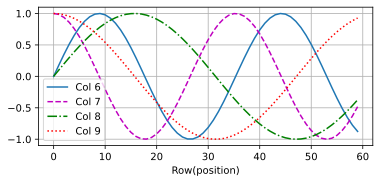

In [26]:
encoding_dim, num_steps = 32, 60
pos_encoding = PositionalEncoding(encoding_dim, 0)
pos_encoding.eval()
X = pos_encoding(torch.zeros((1, num_steps, encoding_dim)))
P = pos_encoding.P[:, :X.shape[1], :]
d2l.plot(torch.arange(num_steps), P[0, :, 6:10].T, xlabel='Row(position)', figsize=(6, 2.5), legend=["Col %d" % d for d in torch.arange(6, 10)])

##### ***绝对位置信息***
###### 为了明白沿着编码维度单调降低的频率与绝对位置信息之间的关系，我们打印出$0,\cdots, 7$的二进制表示形式。正如所看到的，每个数字、每两个数字和每四个数字上的比特值在第一个最低位、第二个最低位和第三个最低位上分别交替。

In [27]:
for i in range(8):
    print(format(i, '03b'))

000
001
010
011
100
101
110
111


###### 在二进制表示中，较高比特位的交替频率低于较低比特位，与下面的热力图所示相似，只是位置编码通过三角函数在编码维度上降低频率。由于输出是浮点数，因此此类连续表示比二进制表示法更节省空间。

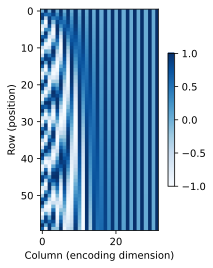

In [28]:
P = P[0, :, :].unsqueeze(0).unsqueeze(0)
d2l.show_heatmaps(P, xlabel='Column (encoding dimension)',
                  ylabel='Row (position)', figsize=(3.5, 4), cmap='Blues')

##### ***相对位置信息***
###### 除了捕获绝对位置信息之外，上述的位置编码还还允许模型学习得到输入序列中相对位置信息。这是因为对于任何确定的位置偏移$\delta$，位置$i+\delta$处的位置编码可以线性投影位置$i$处的位置编码来表示。因为若令$\omega_j = 1/10000^{2j/d}$，对于任何确定的位置偏移$\delta$，任何一对$(p_{i, 2j}, p_{i, 2j+1})$都可以线性投影到$(p_{i+\delta, 2j}, p_{i+\delta, 2j+1})$:
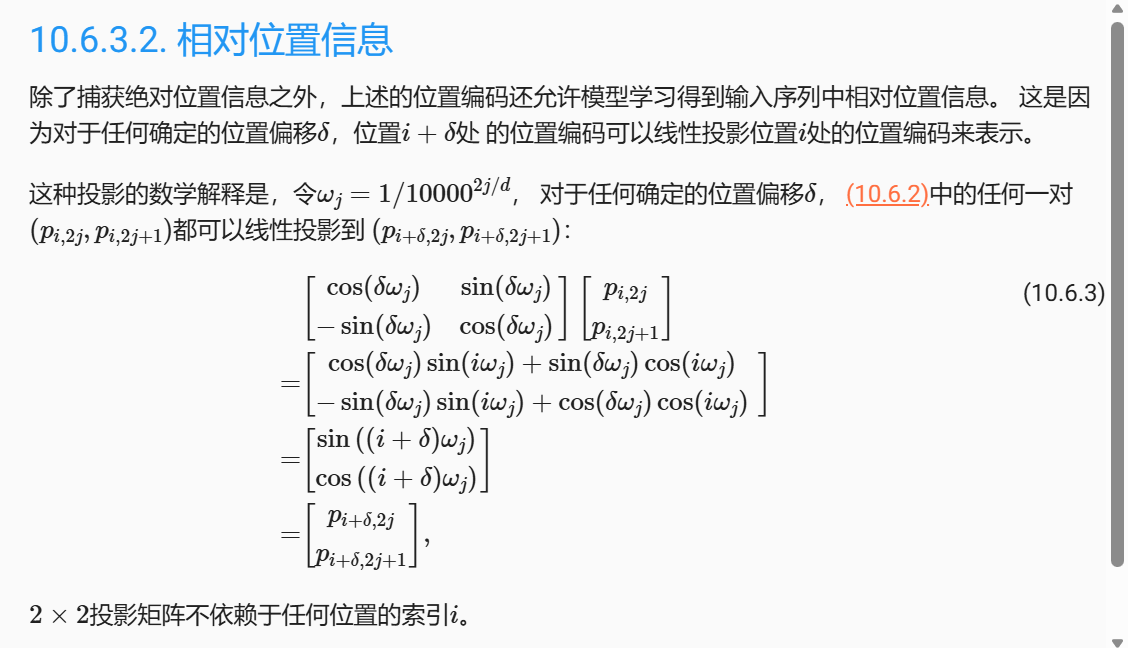